In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors
import seaborn as sns
import plotly.express as px
df = pd.read_csv("youtube_creator_data_sample.csv")
print(df.head())

   Unnamed: 0            timestamp    video_id      category  language region  \
0      987231  2025-08-27 00:23:32  VID_634261         Music   Spanish     PK   
1       79954  2025-02-20 10:15:52  VID_559281        Coding  Japanese     UK   
2      567130  2024-01-30 00:43:55  VID_649652  Tech Reviews   Spanish     BR   
3      500891  2024-01-20 04:20:13  VID_490485     Education  Japanese     BR   
4       55399  2024-02-29 07:43:10  VID_360627        Gaming   Spanish     IN   

   duration_sec  views  likes  comments  shares  sentiment_score  ads_enabled  
0          1633  18258   1381       261      23           -0.456         True  
1           589  50677    653        56     110           -0.089         True  
2          1382  27079    627        92      37            0.049        False  
3          2247  13952    924       144      37            0.901         True  
4           528  15837    699        69      31            0.042         True  


In [2]:
df.head()

,Unnamed: 0,timestamp,video_id,category,language,region,duration_sec,views,likes,comments,shares,sentiment_score,ads_enabled
0,987231,2025-08-27 00:23:32,VID_634261,Music,Spanish,PK,1633,18258,1381,261,23,-0.456,True
1,79954,2025-02-20 10:15:52,VID_559281,Coding,Japanese,UK,589,50677,653,56,110,-0.089,True
2,567130,2024-01-30 00:43:55,VID_649652,Tech Reviews,Spanish,BR,1382,27079,627,92,37,0.049,False
3,500891,2024-01-20 04:20:13,VID_490485,Education,Japanese,BR,2247,13952,924,144,37,0.901,True
4,55399,2024-02-29 07:43:10,VID_360627,Gaming,Spanish,IN,528,15837,699,69,31,0.042,True


In [3]:
df.isna().sum()

Unnamed: 0         0
timestamp          0
video_id           0
category           0
language           0
region             0
duration_sec       0
views              0
likes              0
comments           0
shares             0
sentiment_score    0
ads_enabled        0
dtype: int64

In [4]:
df.describe(include="O")

,timestamp,video_id,category,language,region
count,50000,50000,50000,50000,50000
unique,49985,48646,6,5,5
top,2025-01-06 22:17:22,VID_365500,Tech Reviews,Hindi,US
freq,2,3,8468,10102,10234


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       50000 non-null  int64  
 1   timestamp        50000 non-null  object 
 2   video_id         50000 non-null  object 
 3   category         50000 non-null  object 
 4   language         50000 non-null  object 
 5   region           50000 non-null  object 
 6   duration_sec     50000 non-null  int64  
 7   views            50000 non-null  int64  
 8   likes            50000 non-null  int64  
 9   comments         50000 non-null  int64  
 10  shares           50000 non-null  int64  
 11  sentiment_score  50000 non-null  float64
 12  ads_enabled      50000 non-null  bool   
dtypes: bool(1), float64(1), int64(6), object(5)
memory usage: 4.6+ MB


In [6]:
df['category'] = df['category'].astype('category')
df['language'] = df['language'].astype('category')
df['region'] = df['region'].astype('category')
df['timestamp'] = pd.to_datetime(df["timestamp"])
df['video_id'] = df['video_id'].astype('string')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Unnamed: 0       50000 non-null  int64         
 1   timestamp        50000 non-null  datetime64[ns]
 2   video_id         50000 non-null  string        
 3   category         50000 non-null  category      
 4   language         50000 non-null  category      
 5   region           50000 non-null  category      
 6   duration_sec     50000 non-null  int64         
 7   views            50000 non-null  int64         
 8   likes            50000 non-null  int64         
 9   comments         50000 non-null  int64         
 10  shares           50000 non-null  int64         
 11  sentiment_score  50000 non-null  float64       
 12  ads_enabled      50000 non-null  bool          
dtypes: bool(1), category(3), datetime64[ns](1), float64(1), int64(6), string(1)
memory usage: 3

In [8]:
df[df.duplicated(subset=['timestamp','video_id', 'category', 'language', 'region', 'duration_sec', 'views', 'likes', 'comments','shares','sentiment_score','ads_enabled'   ])]

,Unnamed: 0,timestamp,video_id,category,language,region,duration_sec,views,likes,comments,shares,sentiment_score,ads_enabled


In [9]:
df=df.drop('Unnamed: 0', axis=1)
df.head(2)

,timestamp,video_id,category,language,region,duration_sec,views,likes,comments,shares,sentiment_score,ads_enabled
0,2025-08-27 00:23:32,VID_634261,Music,Spanish,PK,1633,18258,1381,261,23,-0.456,True
1,2025-02-20 10:15:52,VID_559281,Coding,Japanese,UK,589,50677,653,56,110,-0.089,True


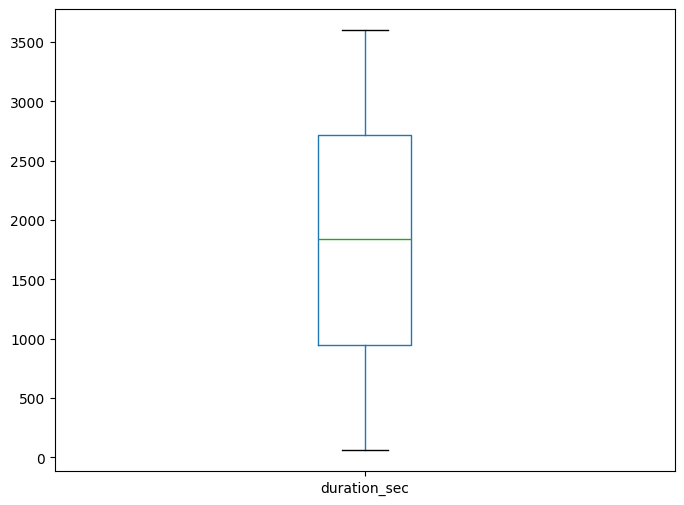

In [10]:
plt.figure(figsize=(8, 6))
df.boxplot(column='duration_sec')
plt.grid(None)
plt.show()

In [11]:
df_less_views = df[df['views'] < 35000]

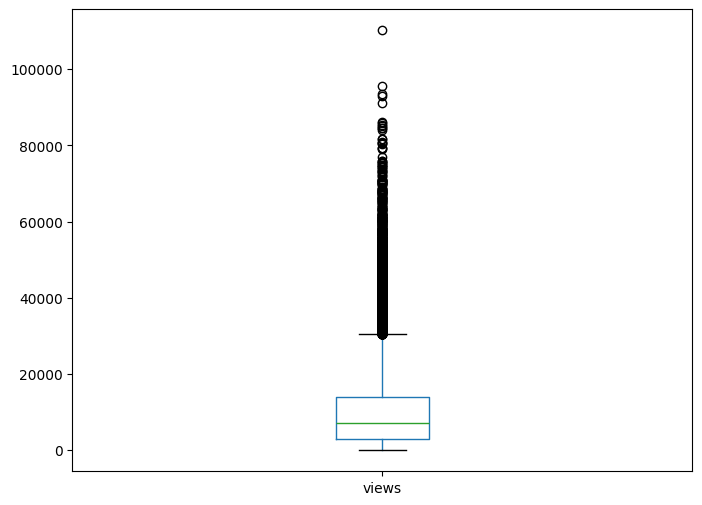

In [12]:
plt.figure(figsize=(8, 6))
df.boxplot(column='views')
plt.grid(None)
plt.show()

In [13]:
df=df[df.views<80000]

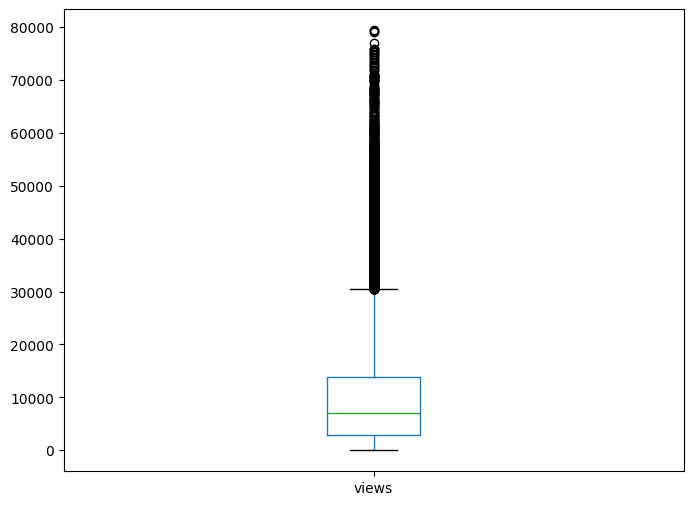

In [14]:
plt.figure(figsize=(8, 6))
df.boxplot(column='views')
plt.grid(None)
plt.show()

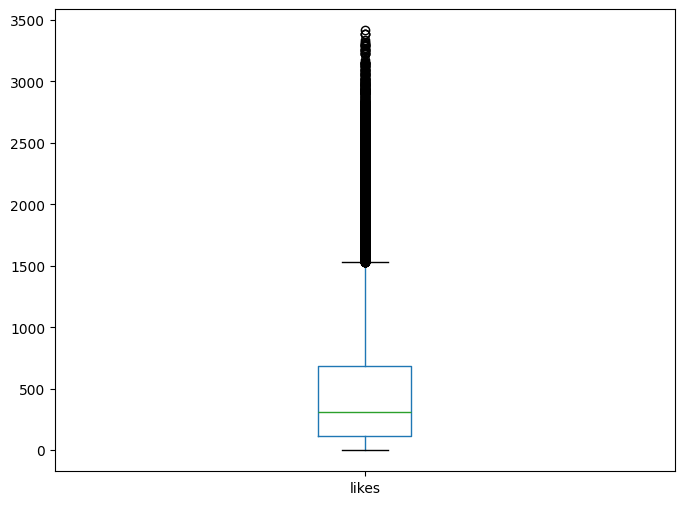

In [15]:
plt.figure(figsize=(8, 6))
df_less_views.boxplot(column='likes')
plt.grid(None)
plt.show()

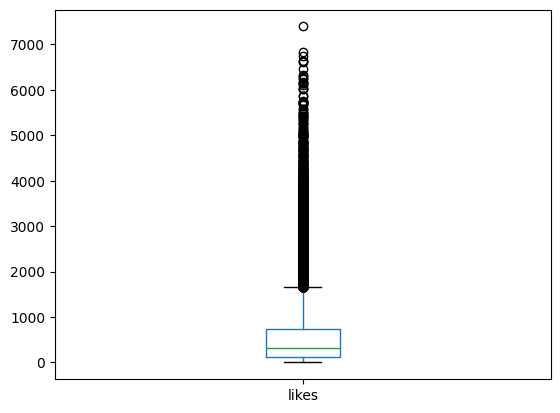

In [16]:
df.boxplot(column='likes')
plt.grid(None)
plt.show()

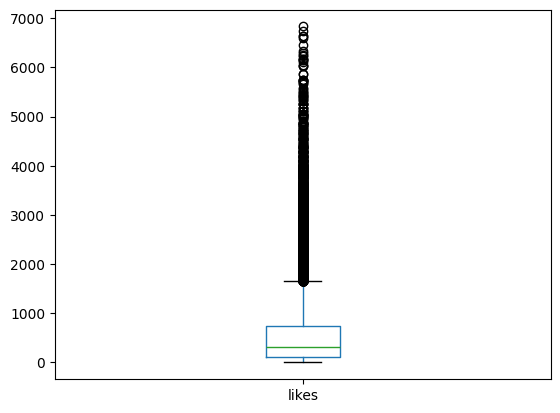

In [17]:
df=df[df.likes<7000]
df.boxplot(column='likes')
plt.grid(None)
plt.show()

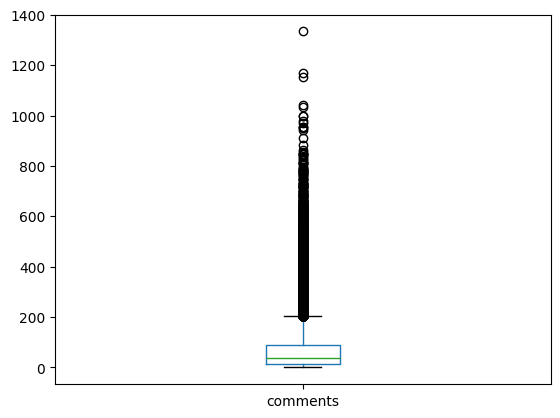

In [18]:
df.boxplot(column='comments')
plt.grid(None)
plt.show()

In [19]:
df=df[df.comments<1100]
df=df[df.shares<350]

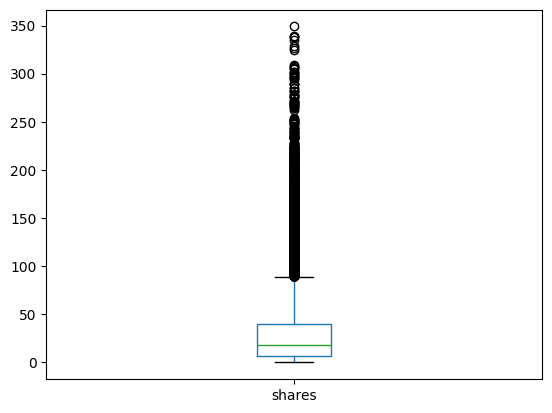

In [20]:
df.boxplot(column='shares')
plt.grid(None)
plt.show()

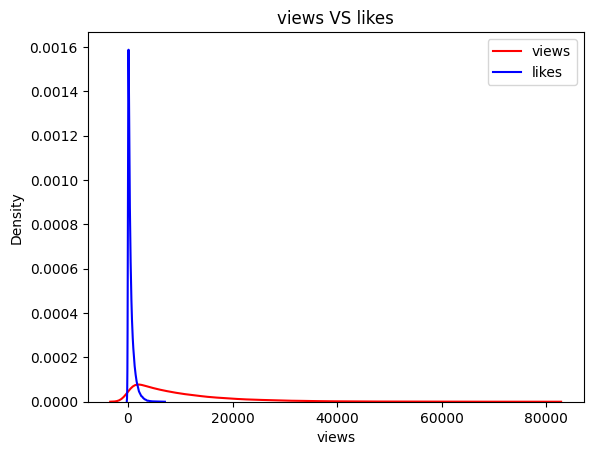

In [21]:
sns.kdeplot(df.views, color='red')
sns.kdeplot(df.likes, color='blue')
plt.title('views VS likes')
plt.legend(['views','likes'])
plt.show()

<Axes: xlabel='views', ylabel='likes'>

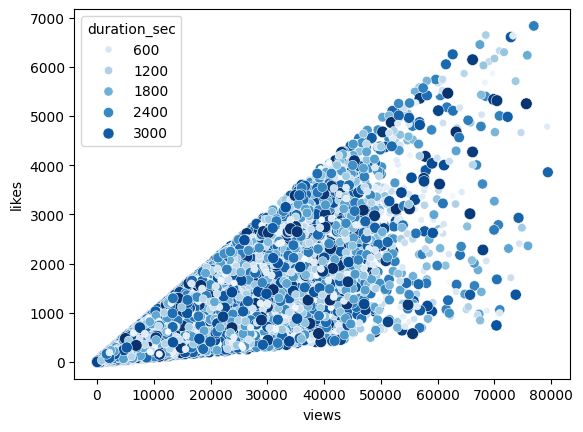

In [22]:
sns.scatterplot(data = df, x='views', y='likes', size='duration_sec', hue = 'duration_sec', palette='Blues')

<Axes: >

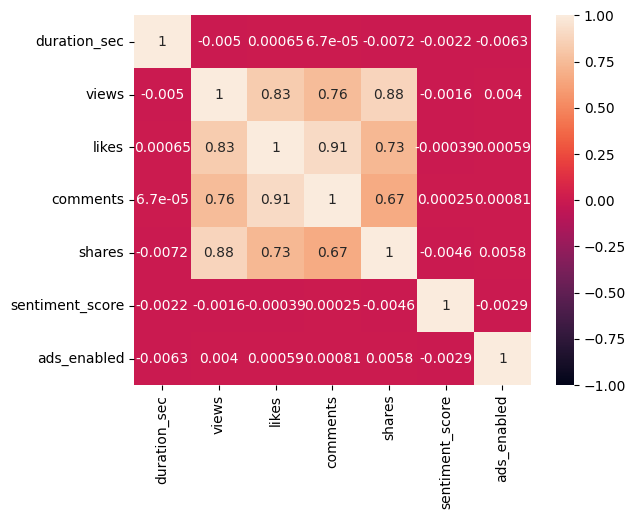

In [23]:
columns = ['duration_sec', 'views', 'likes', 'comments','shares','sentiment_score','ads_enabled'   ]
corr = df[columns].corr()
sns.heatmap(corr,
        xticklabels=corr.columns,
        yticklabels=corr.columns,
        annot=True,
        vmin=-1, vmax=1)

<Axes: xlabel='duration_sec', ylabel='ads_enabled'>

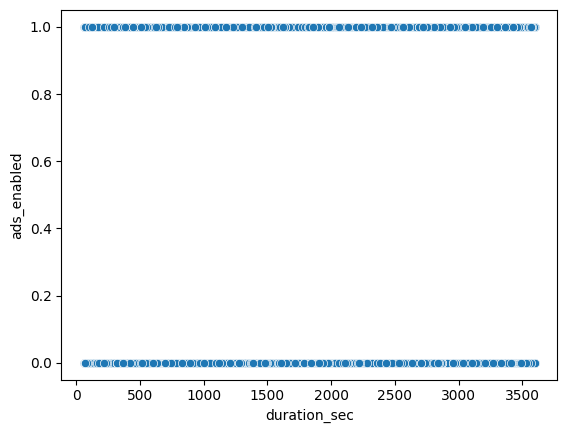

In [24]:
sns.scatterplot(data = df, x='duration_sec', y='ads_enabled')

In [25]:
df.to_csv('calean_dataset.csv', index=False)

In [ ]:
from sklearn.preprocessing import RobustScaler

columns = ['duration_sec', 'views', 'likes', 'comments','shares','sentiment_score']
df_to_scale = df[columns]
df_scaled = RobustScaler().fit_transform(df_to_scale)

In [37]:
plt.rcParams['figure.figsize'] = [16, 8]

**KMeans**

In [57]:
from sklearn.cluster import KMeans

k_values = range(2,200)
inertia = []
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=0).fit(df_scaled)
    inertia.append(kmeans.inertia_)

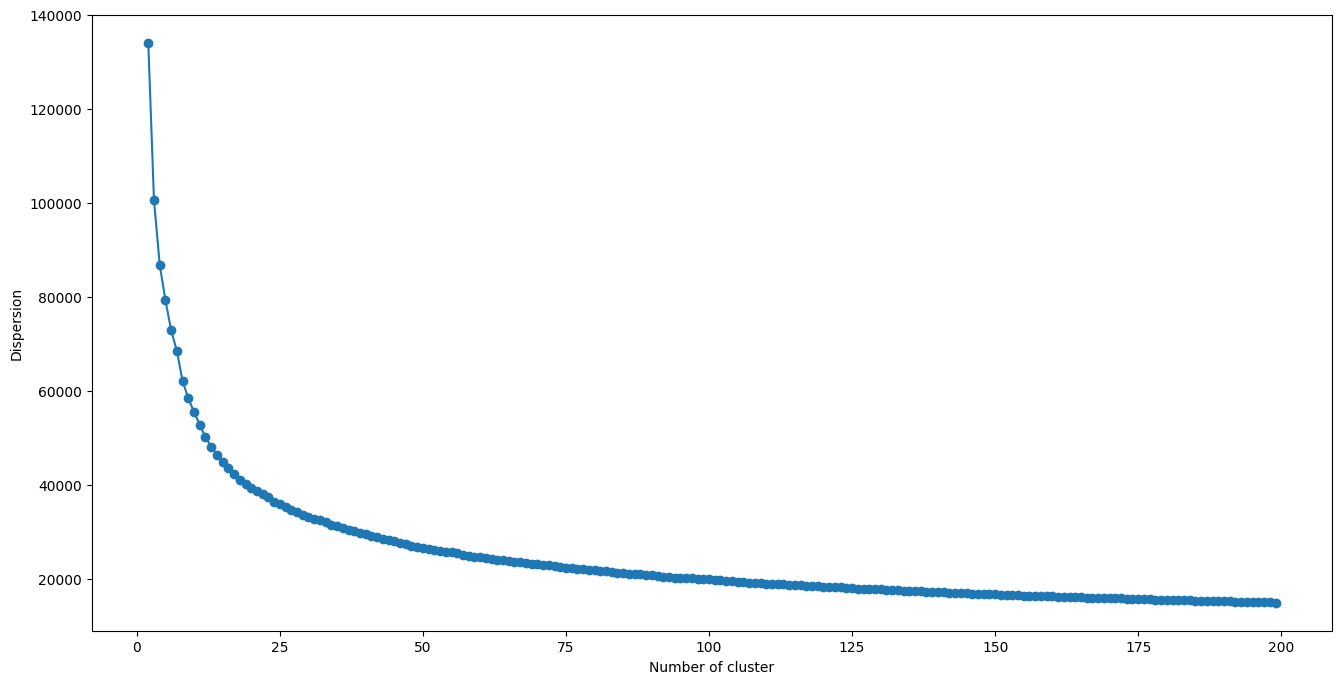

In [58]:
plt.plot(k_values, inertia, marker = "o")
plt.xlabel("Number of cluster")
plt.ylabel("Dispersion")
plt.show()

In [59]:
k_values = range(2,91)
inertia = []
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=0).fit(df_scaled)
    inertia.append(kmeans.inertia_)

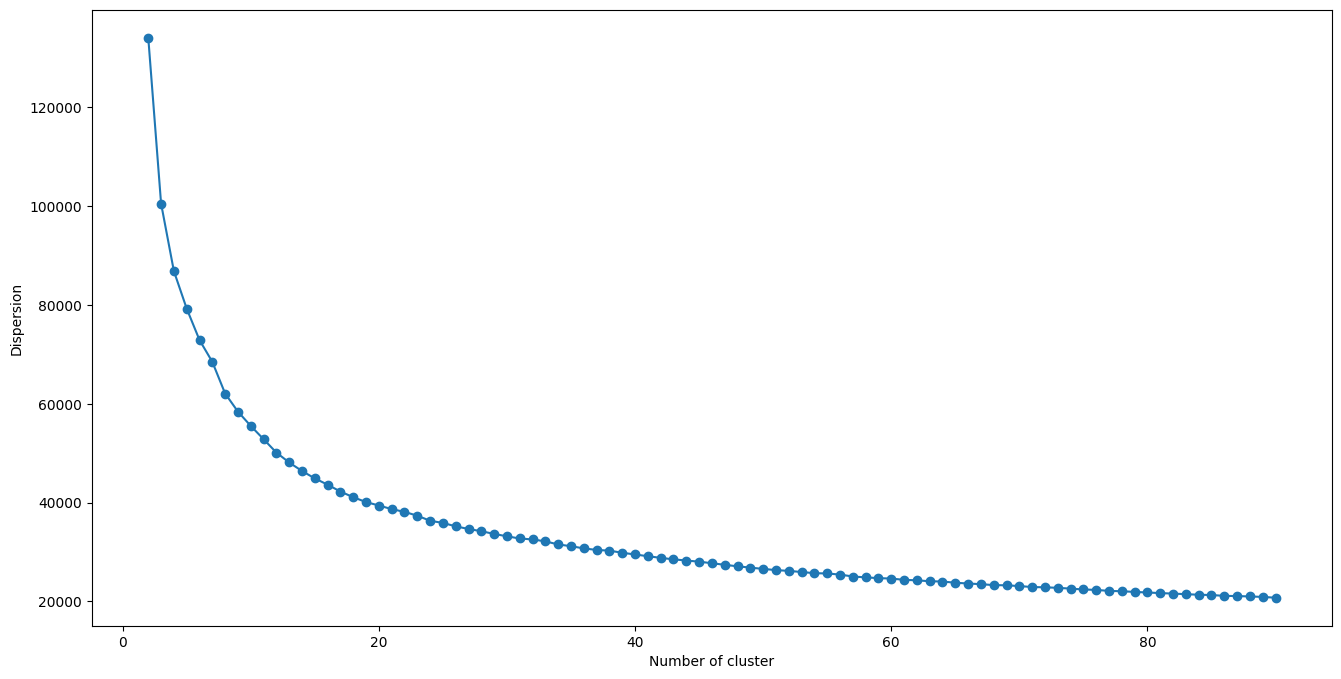

In [60]:
plt.plot(k_values, inertia, marker = "o")
plt.xlabel("Number of cluster")
plt.ylabel("Dispersion")
plt.show()